# Try out different distance metrics

In [1]:
import warnings
from os.path import join, isfile
from typing import Dict, List

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "/vol/data/dataset-similarity"
FILE_PATH = "adata.h5ad"

if not isfile(FILE_PATH):
    adata = anndata.concat([
        sc.read_h5ad(join(DATA_PATH, "01ad3cd7-3929-4654-84c0-6db05bd5fd59_processed.h5ad")),
        sc.read_h5ad(join(DATA_PATH, "b0e547f0-462b-4f81-b31b-5b0a5d96f537_processed.h5ad"))
    ], label="dataset", keys=["query", "ref"])
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="dataset")
    adata = adata[:, adata.var.highly_variable]
    sc.tl.pca(adata, n_comps=128)
    adata.write_h5ad(FILE_PATH)
else:
    print("Loading cached anndata file...")
    adata = anndata.read_h5ad(FILE_PATH)


Loading cached anndata file...


In [3]:
adata

AnnData object with n_obs × n_vars = 1659838 × 2000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'dataset'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [4]:
adata_ref = adata[adata.obs.dataset == "ref"]
adata_query = adata[adata.obs.dataset == "query"]

In [5]:
adata_query

View of AnnData object with n_obs × n_vars = 600929 × 2000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'dataset'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [6]:
adata_ref

View of AnnData object with n_obs × n_vars = 1058909 × 2000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'dataset'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [7]:
def plot_label_distances(
    label_distances: np.ndarray, 
    labels1: List[str], 
    labels2: List[str],
    author_to_cxg_celltype: Dict[str, str]
):
    distances = pd.DataFrame(
        data=label_distances,
        index=labels1,
        columns=labels2
    )
    
    order = lambda ct_author: list(
        map(
            lambda x: x[0], # only return author cell type
            sorted(
                zip(
                    ct_author, 
                    [author_to_cxg_celltype[ct] for ct in ct_author]
                ), 
                key=lambda x: x[1]
            ) # sort by CxG cell type
        )
    )

    fig, ax = plt.subplots(figsize=(12, 12))
    sns.heatmap(
        distances.loc[order(labels1), :].loc[:, order(labels2)], 
        square=True
    )

    return ax


In [8]:
author_to_cxg_mapping = (
    adata.obs[["cell_type", "cell_type_author"]]
    .drop_duplicates()
    .set_index("cell_type_author")["cell_type"]
    .to_dict()
)

## Bures-Wasserstein distance in PCA space

In [9]:
from datasim.label_distance import bures_wasserstein_label_distance

In [10]:
bw_distance_128 = bures_wasserstein_label_distance(
    adata_ref.obsm["X_pca"][:, :128],
    adata_query.obsm["X_pca"][:, :128],
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

Calcualting mean vectors...
Calcualting covariance matrices...
Computing label distances...


  0%|          | 0/1360 [00:00<?, ?it/s]

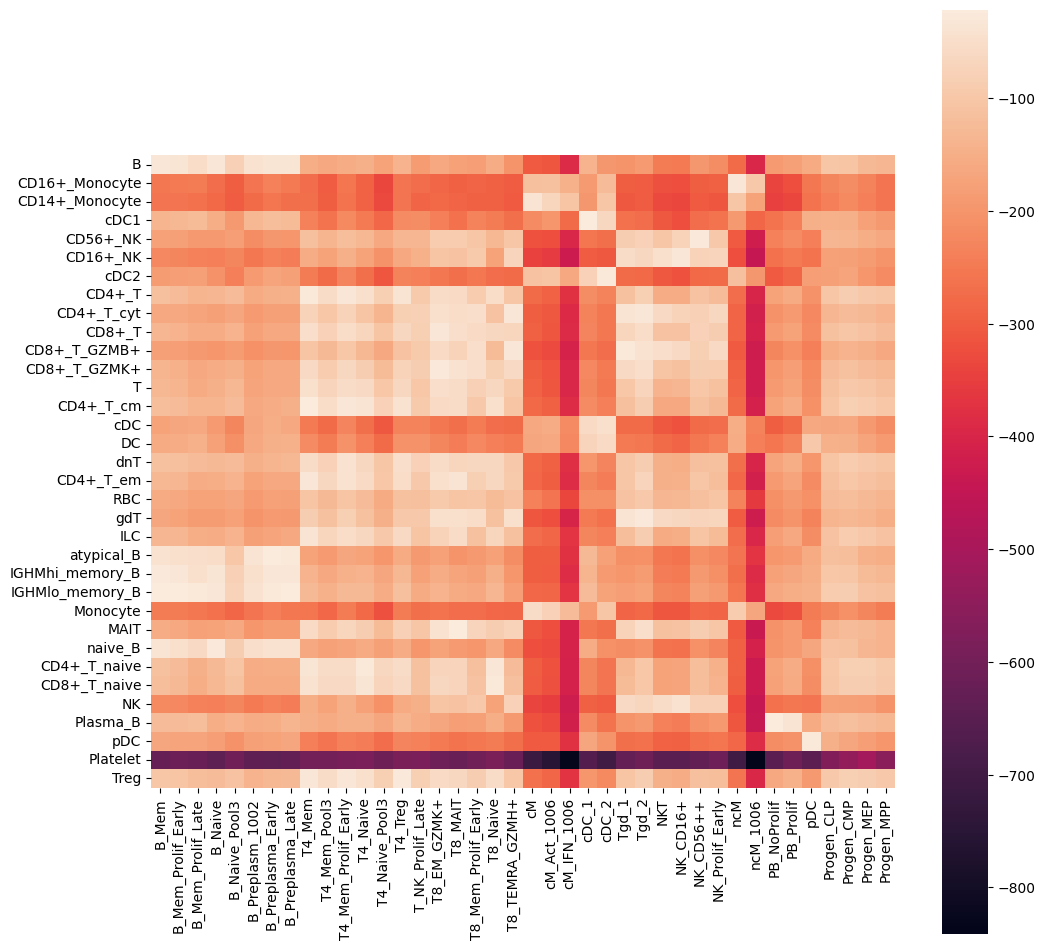

In [11]:
ax = plot_label_distances(
    -bw_distance_128.to_numpy(), 
    bw_distance_128.index.tolist(), 
    bw_distance_128.columns.tolist(),
    author_to_cxg_mapping
)

## Spearman correlation of centroids

In [12]:
from datasim.label_distance import spearmanr_label_distance

In [13]:
spearmanr_distance = spearmanr_label_distance(
    adata_ref.X,
    adata_query.X,
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

Calculating mean vectors...
Computing label distances...


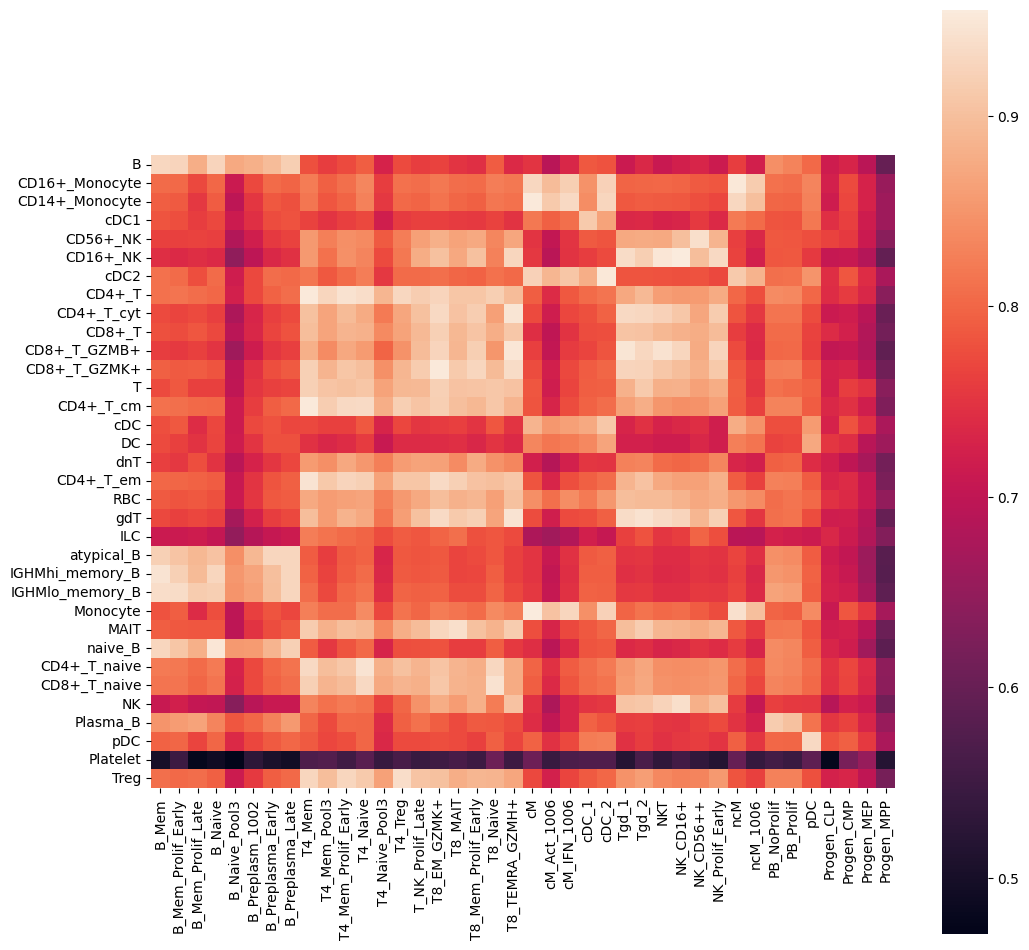

In [14]:
ax = plot_label_distances(
    spearmanr_distance.to_numpy(), 
    spearmanr_distance.index.tolist(), 
    spearmanr_distance.columns.tolist(), 
    author_to_cxg_mapping
)

## Overlap of differentially expressed genes

In [15]:
from datasim.label_distance import de_gene_overlap_label_distance

In [16]:
# ignore warnings here as scanpy.tl.rank_genes_groups throws a lot of warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    de_gene_overlap = de_gene_overlap_label_distance(adata_query, adata_ref, "cell_type_author")

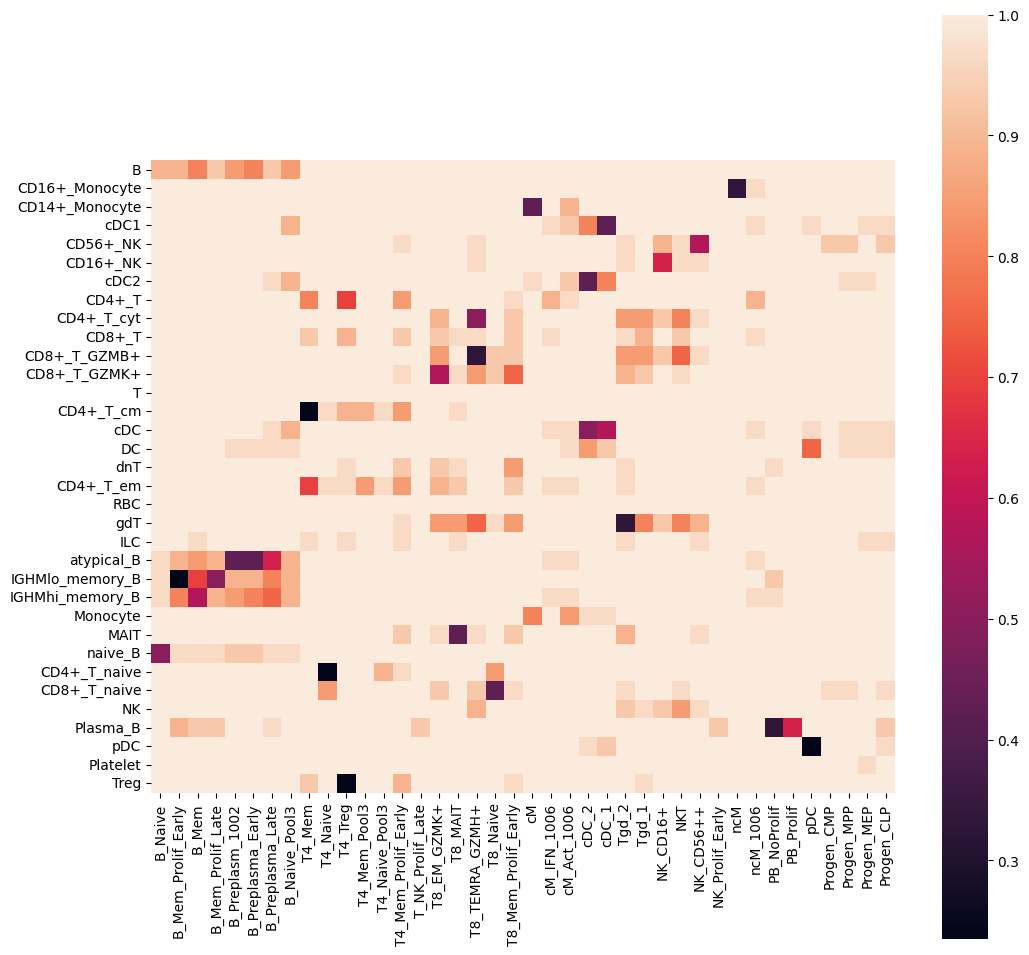

In [17]:
ax = plot_label_distances(
    de_gene_overlap.to_numpy(), 
    de_gene_overlap.index.tolist(), 
    de_gene_overlap.columns.tolist(), 
    author_to_cxg_mapping
)